In [ ]:
# 1. Instalando as dependências
!pip install qiskit==2.3.0 qiskit-aer==0.17.0 pylatexenc matplotlib --quiet

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 162.6/162.6 kB 5.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 95.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.4/12.4 MB 67.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.2/2.2 MB 62.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 54.5/54.5 kB 3.7 MB/s eta 0:00:00


## Construção do circuito

In [ ]:
# Importando as bibliotecas
from qiskit import QuantumCircuit, QuantumRegister, ClassicalRegister
from qiskit_aer import AerSimulator
from qiskit.visualization import plot_histogram
import matplotlib.pyplot as plt
import numpy as np

In [ ]:
# ============================================================
# FUNÇÕES AUXILIARES
# ============================================================

def print_secao(titulo):
    print("\n" + "═" * 58)
    print(f"  {titulo}")
    print("═" * 58)

def print_estado(theta, phi):
    a  = np.cos(theta / 2)
    b  = np.exp(1j * phi) * np.sin(theta / 2)
    p0 = abs(a) ** 2
    p1 = abs(b) ** 2
    print(f"\n  |ψ⟩ = {a:.3f}|0⟩  +  ({b:.3f})|1⟩")
    print(f"\n  Probabilidades teóricas:")
    print(f"    P(|0⟩) = {p0:.3f}  ({100*p0:.1f}%)")
    print(f"    P(|1⟩) = {p1:.3f}  ({100*p1:.1f}%)")


In [ ]:
# ============================================================
# 1. ESTADO A TELEPORTAR
# ============================================================
print_secao("PASSO 0 — Estado que Alice quer teleportar")

theta = np.pi / 3   # ← mude esta variável para experimentar outros estados (em radianos)
phi   = np.pi / 4   # ← mude esta variável para experimentar outros estados (em radianos)

print(f"\n  Parâmetros: θ = π/3,  φ = π/4")
print_estado(theta, phi)

p0_teorico = np.cos(theta / 2) ** 2
p1_teorico = np.sin(theta / 2) ** 2


══════════════════════════════════════════════════════════
  PASSO 0 — Estado que Alice quer teleportar
══════════════════════════════════════════════════════════

  Parâmetros: θ = π/3,  φ = π/4

  |ψ⟩ = 0.866|0⟩  +  (0.354+0.354j)|1⟩

  Probabilidades teóricas:
    P(|0⟩) = 0.750  (75.0%)
    P(|1⟩) = 0.250  (25.0%)


In [ ]:
# ============================================================
# 2. CONSTRUÇÃO DO CIRCUITO
# ============================================================
q = QuantumRegister(3, 'q')
c = ClassicalRegister(2, 'c')
b = ClassicalRegister(1, 'b')
qc = QuantumCircuit(q, c, b)

# Passo 0: preparar |ψ⟩


# Passo 1: par de Bell


# Passo 2: operações de Alice


# Passo 3: medições de Alice


# Passo 4: correções de Bob
with qc.if_test((c[1], 1)):
# Colocar as portas Z de correção de Bob aqui
with qc.if_test((c[0], 1)):
# Colocar as portas Z de correção de Bob aqui

# Passo 5: medição de Bob
qc.measure(q[2], b[0])


══════════════════════════════════════════════════════════
  CIRCUITO COMPLETO
══════════════════════════════════════════════════════════


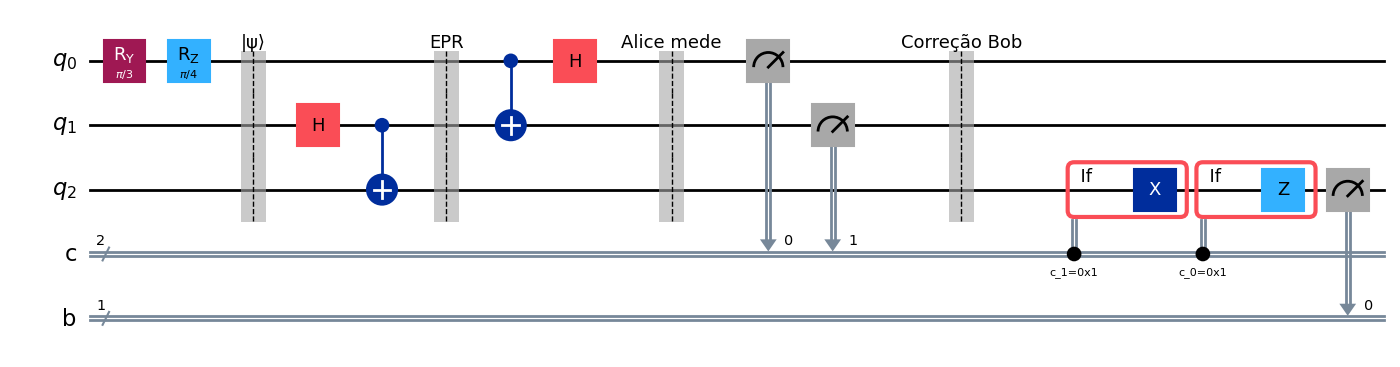

In [ ]:
# ============================================================
# 3. MOSTRAR CIRCUITO
# ============================================================
print_secao("CIRCUITO COMPLETO")
qc.draw('mpl', fold=90)

In [ ]:
# ============================================================
# 4. SIMULAÇÃO
# ============================================================

simulator = AerSimulator()
job       = simulator.run(qc, shots=4096)
counts    = job.result().get_counts()

In [ ]:
# ============================================================
# 5. SEPARAR RESULTADOS
# ============================================================
correcoes = {'00': 'nada', '01': 'X', '10': 'Z', '11': 'X + Z'}
alice_resultados = {}
bob_counts = {'0': 0, '1': 0}

for bitstring, freq in counts.items():
    partes    = bitstring.strip().split()
    bob_bit   = partes[0]
    alice_bits = partes[1]
    bob_counts[bob_bit] = bob_counts.get(bob_bit, 0) + freq
    alice_resultados[alice_bits] = alice_resultados.get(alice_bits, 0) + freq

total  = sum(bob_counts.values())
p0_bob = bob_counts.get('0', 0) / total
p1_bob = bob_counts.get('1', 0) / total


In [ ]:
# ============================================================
# 6. TABELA DE CORREÇÕES
# ============================================================
print_secao("O que Alice mediu e Bob corrigiu")
print("\n  ┌──────────────┬─────────────┬──────────────────────┐")
print("  │ Alice mediu  │ Bob aplicou │ Frequência           │")
print("  ├──────────────┼─────────────┼──────────────────────┤")
for bits in sorted(alice_resultados):
    freq = alice_resultados[bits]
    corr = correcoes.get(bits, '?')
    pct  = 100 * freq / total
    print(f"  │  c1c0 = {bits}   │  {corr:<10} │  {freq:4d} shots ({pct:.1f}%)  │")
print("  └──────────────┴─────────────┴──────────────────────┘")


══════════════════════════════════════════════════════════
  O que Alice mediu e Bob corrigiu
══════════════════════════════════════════════════════════

  ┌──────────────┬─────────────┬──────────────────────┐
  │ Alice mediu  │ Bob aplicou │ Frequência           │
  ├──────────────┼─────────────┼──────────────────────┤
  │  c1c0 = 00   │  nada       │   964 shots (23.5%)  │
  │  c1c0 = 01   │  X          │  1055 shots (25.8%)  │
  │  c1c0 = 10   │  Z          │  1095 shots (26.7%)  │
  │  c1c0 = 11   │  X + Z      │   982 shots (24.0%)  │
  └──────────────┴─────────────┴──────────────────────┘


In [ ]:
# ============================================================
# 7. COMPARAÇÃO ESTADO ORIGINAL × RECEBIDO
# ============================================================
print_secao("RESULTADO FINAL: Alice × Bob")
print(f"""
  ╔══════════════════════════════════════════════════════╗
  ║         ALICE (original)      BOB (recebido)        ║
  ╠══════════════════════════════════════════════════════╣
  ║  P(|0⟩)    {p0_teorico*100:>8.1f}%           {p0_bob*100:>8.1f}%           ║
  ║  P(|1⟩)    {p1_teorico*100:>8.1f}%           {p1_bob*100:>8.1f}%           ║
  ╚══════════════════════════════════════════════════════╝
""")

fidelidade = (np.sqrt(p0_bob * p0_teorico) + np.sqrt(p1_bob * p1_teorico)) ** 2
print(f"  Fidelidade do teleporte: {fidelidade:.4f}  ", end="")
print(" Sucesso!" if fidelidade > 0.95 else " Verifique o circuito.")


══════════════════════════════════════════════════════════
  RESULTADO FINAL: Alice × Bob
══════════════════════════════════════════════════════════

  ╔══════════════════════════════════════════════════════╗
  ║         ALICE (original)      BOB (recebido)        ║
  ╠══════════════════════════════════════════════════════╣
  ║  P(|0⟩)        75.0%               76.3%           ║
  ║  P(|1⟩)        25.0%               23.7%           ║
  ╚══════════════════════════════════════════════════════╝

  Fidelidade do teleporte: 0.9998   Sucesso!


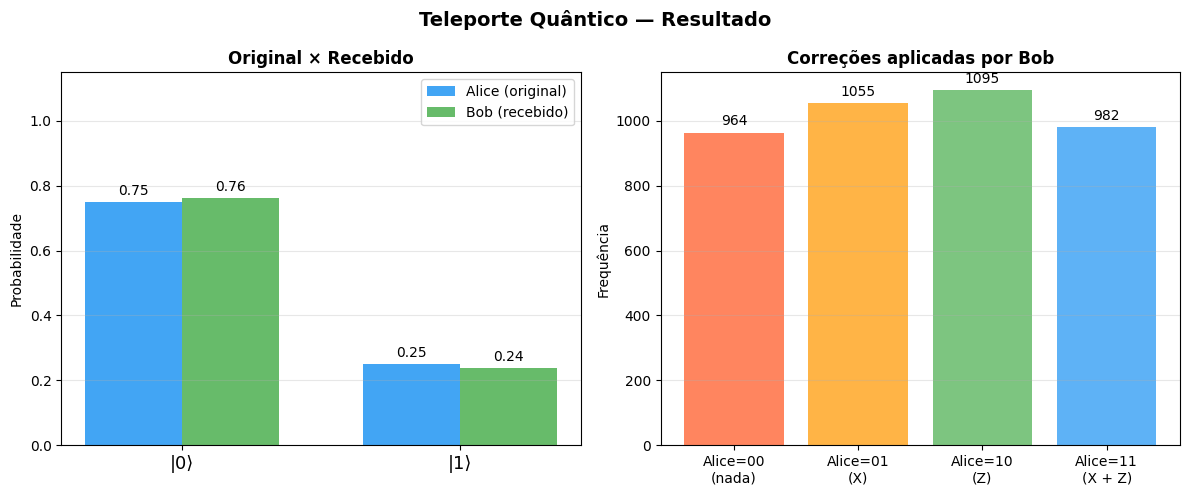

In [ ]:
# ============================================================
# 8. GRÁFICOS
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Teleporte Quântico — Resultado", fontsize=14, fontweight='bold')

# ── Barras: Alice vs Bob ─────────────────────────────────────
x       = np.arange(2)
largura = 0.35
bars1 = axes[0].bar(x - largura/2, [p0_teorico, p1_teorico], largura,
                    label='Alice (original)', color='#2196F3', alpha=0.85)
bars2 = axes[0].bar(x + largura/2, [p0_bob, p1_bob], largura,
                    label='Bob (recebido)',   color='#4CAF50', alpha=0.85)
axes[0].set_xticks(x)
axes[0].set_xticklabels(['|0⟩', '|1⟩'], fontsize=13)
axes[0].set_ylabel('Probabilidade')
axes[0].set_ylim(0, 1.15)
axes[0].set_title('Original × Recebido', fontweight='bold')
axes[0].legend()
axes[0].bar_label(bars1, fmt='%.2f', padding=3)
axes[0].bar_label(bars2, fmt='%.2f', padding=3)
axes[0].grid(axis='y', alpha=0.3)

# ── Correções de Bob ─────────────────────────────────────────
labels = [f'Alice={k}\n({correcoes[k]})' for k in sorted(alice_resultados)]
vals   = [alice_resultados[k] for k in sorted(alice_resultados)]
cores  = ['#FF7043', '#FFA726', '#66BB6A', '#42A5F5']
bars3  = axes[1].bar(labels, vals, color=cores, alpha=0.85)
axes[1].set_title('Correções aplicadas por Bob', fontweight='bold')
axes[1].set_ylabel('Frequência')
axes[1].bar_label(bars3, padding=3)
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig("teleporte_didatico.png", dpi=150, bbox_inches='tight')
plt.show()